<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


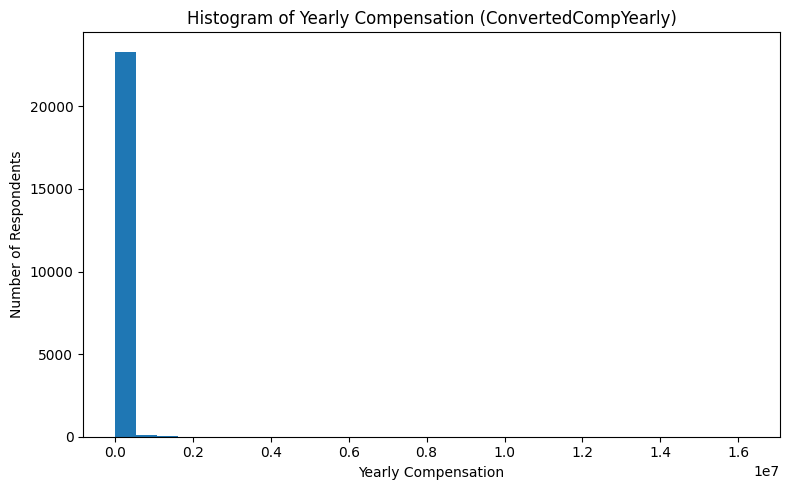

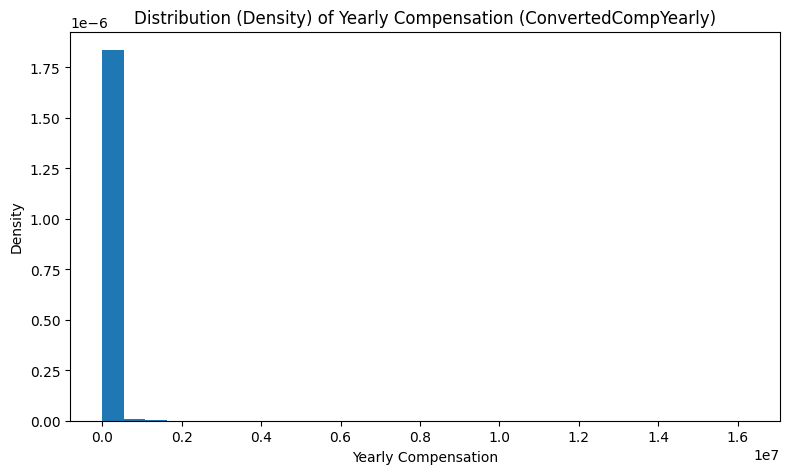

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure ConvertedCompYearly is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df["ConvertedCompYearly"].dropna(), bins=30)
plt.title("Histogram of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("Yearly Compensation")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

# Distribution plot (density using histogram with density=True)
plt.figure(figsize=(8, 5))
plt.hist(df["ConvertedCompYearly"].dropna(), bins=30, density=True)
plt.title("Distribution (Density) of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("Yearly Compensation")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
import pandas as pd

# Ensure ConvertedCompYearly is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Filter full-time employees
full_time = df[df["Employment"] == "Employed, full-time"]

# Calculate median compensation
median_full_time_comp = full_time["ConvertedCompYearly"].median()
print(median_full_time_comp)


69814.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



In [5]:
import pandas as pd

# Ensure compensation is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Keep rows with valid country + compensation
df_cc = df[["Country", "ConvertedCompYearly"]].dropna()

# Select top N countries by respondent count (to avoid clutter)
top_n = 10
top_countries = df_cc["Country"].value_counts().head(top_n).index

df_top = df_cc[df_cc["Country"].isin(top_countries)]


/tmp/ipykernel_876/1079363226.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=countries_ordered, showfliers=True)


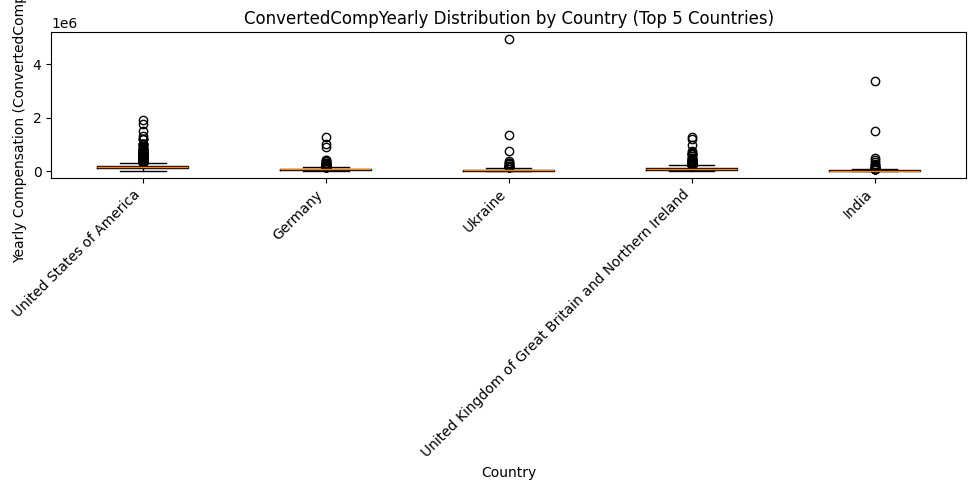

/tmp/ipykernel_876/1079363226.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=countries_ordered, showfliers=True)


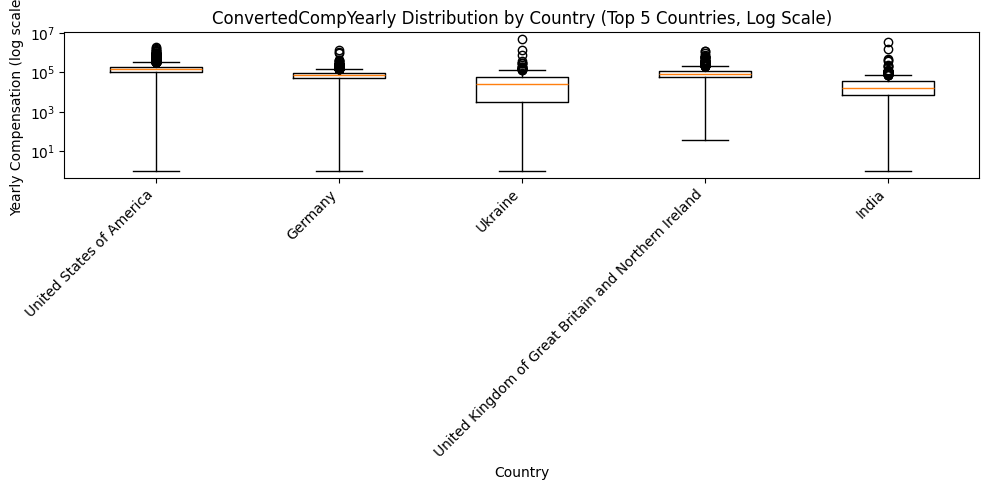

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure compensation is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Keep valid rows
df_cc = df[["Country", "ConvertedCompYearly"]].dropna()

# Reduce to top 5 countries by respondent count
top_n = 5
top_countries = df_cc["Country"].value_counts().head(top_n).index
df_top = df_cc[df_cc["Country"].isin(top_countries)]

# Prepare data for boxplot
countries_ordered = df_top["Country"].value_counts().index
data_to_plot = [df_top[df_top["Country"] == c]["ConvertedCompYearly"].values for c in countries_ordered]

# Box plot (normal scale)
plt.figure(figsize=(10, 5))
plt.boxplot(data_to_plot, labels=countries_ordered, showfliers=True)
plt.title("ConvertedCompYearly Distribution by Country (Top 5 Countries)")
plt.xlabel("Country")
plt.ylabel("Yearly Compensation (ConvertedCompYearly)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Box plot (log scale - recommended for skewed salary data)
plt.figure(figsize=(10, 5))
plt.boxplot(data_to_plot, labels=countries_ordered, showfliers=True)
plt.yscale("log")
plt.title("ConvertedCompYearly Distribution by Country (Top 5 Countries, Log Scale)")
plt.xlabel("Country")
plt.ylabel("Yearly Compensation (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [8]:
import pandas as pd

# Ensure ConvertedCompYearly is numeric
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

# Drop rows with missing compensation (needed for outlier detection)
df_comp = df.dropna(subset=["ConvertedCompYearly"]).copy()

# IQR method to detect outliers
Q1 = df_comp["ConvertedCompYearly"].quantile(0.25)
Q3 = df_comp["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create refined DataFrame excluding outliers
df_refined = df_comp[
    (df_comp["ConvertedCompYearly"] >= lower_bound) &
    (df_comp["ConvertedCompYearly"] <= upper_bound)
].copy()

# Validate size
print("Original (non-missing comp) size:", df_comp.shape)
print("Refined (outliers removed) size:", df_refined.shape)
print("Rows removed:", df_comp.shape[0] - df_refined.shape[0])


Original (non-missing comp) size: (23435, 114)
Refined (outliers removed) size: (22457, 114)
Rows removed: 978


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric types
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")
df["WorkExp"] = pd.to_numeric(df["WorkExp"], errors="coerce")
df["JobSatPoints_1"] = pd.to_numeric(df["JobSatPoints_1"], errors="coerce")

# Keep only relevant columns and drop missing rows for correlation
corr_df = df[["ConvertedCompYearly", "WorkExp", "JobSatPoints_1"]].dropna()

# Calculate correlation matrix
corr_matrix = corr_df.corr(method="pearson")
corr_matrix


,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.153182,0.020156
WorkExp,0.153182,1.000000,-0.028839
JobSatPoints_1,0.020156,-0.028839,1.000000


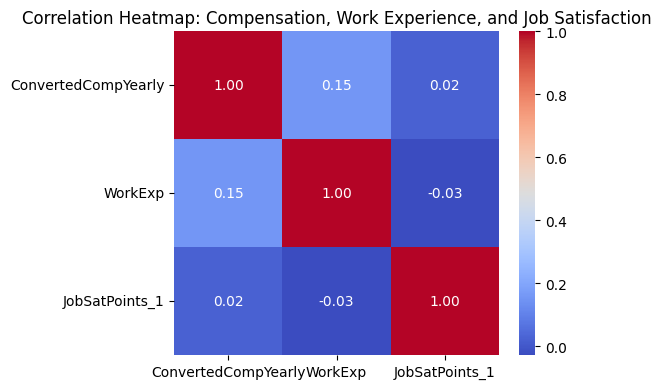

In [10]:
# Visualize correlation matrix with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap: Compensation, Work Experience, and Job Satisfaction")
plt.tight_layout()
plt.show()


<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


In [ ]:
## Write your code here

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
